In [106]:
library(edgeR)
library(anndata)
library(dplyr)
library(readr)
library(pheatmap)
library(stringr)
library(ggplot2)
library(gridExtra)

In [107]:
object <- "pdata_muscle_D1_non_filtered.h5ad"
adata <- read_h5ad(paste0("../AnnData_Objects/Megabulks/",object))
print(adata)

AnnData object with n_obs × n_vars = 5 × 18085
    obs: 'sample_id', 'anatomical_cluster', 'psbulk_cells', 'psbulk_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'avg_counts_per_gene_per_pseudobulk'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'anatomical_cluster_colors'
    layers: 'psbulk_props'


In [108]:
rownames(adata) <- rownames(adata$X) %>% str_replace( "id_constant_", "")
head(adata$X)

,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,C1orf159,⋯,MT-ND2,MT-CO2,MT-ATP6,MT-CO3,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB
EOM,4,19,7,0,0,25,0,54,0,6,⋯,137,293,533,885,120,314,477,72,84,389
above_tongue,0,1,0,0,0,1,0,5,0,3,⋯,26,55,81,164,22,57,88,10,16,68
arches,4,7,0,0,0,18,3,38,0,7,⋯,128,254,353,628,69,292,331,56,55,298
masseter,27,21,11,0,0,38,7,78,0,13,⋯,400,895,1432,2405,298,885,1272,185,220,1086
tongue,0,2,2,0,0,5,1,17,0,2,⋯,67,139,217,349,61,143,159,26,31,157


In [109]:
adata$layers['counts'] <- adata$X

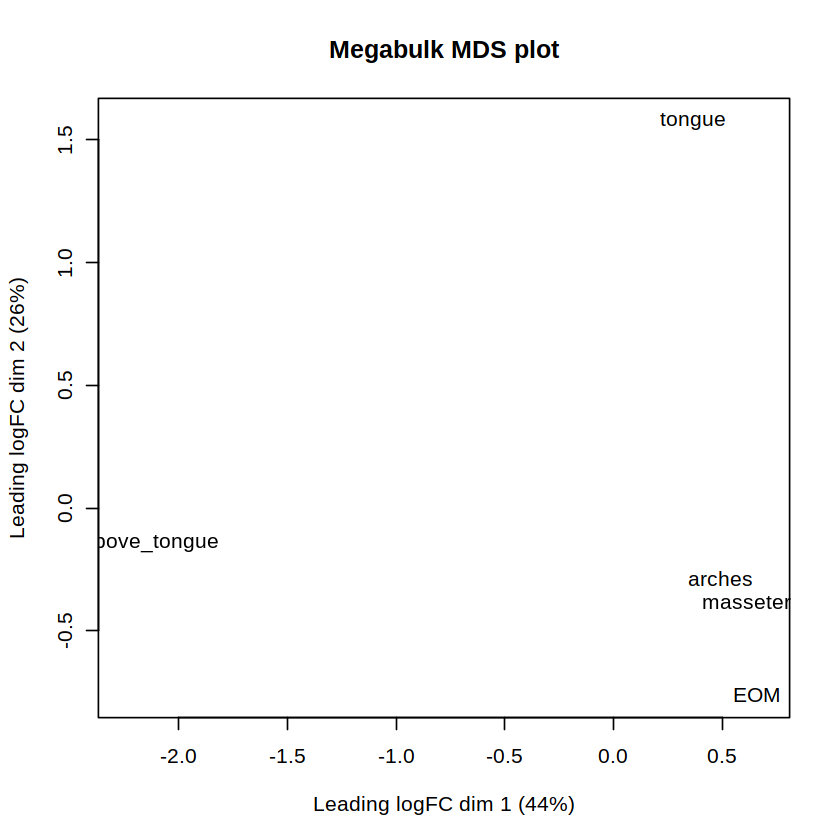

In [110]:
# Suppose megabulk_counts is a matrix with columns = clusters, rows = genes

dge <- DGEList(counts = t(adata$X)) # tranpose as it's expecting columns=clusters and rows=genes
dge <- calcNormFactors(dge)
logCPM <- cpm(dge, log=TRUE)

# MDS plot
plotMDS(dge, labels = colnames(dge$counts), main = "Megabulk MDS plot")

## Pheatmaps - Plot genes derived from the pseudobulk analysis

In [111]:
pheatmap_plotting <- function(markers_path, cluster, logCPM, scale_, width=1200, height=2000) { 
    tmp <- suppressMessages(readr::read_tsv(paste0(markers_path,cluster,"_top_markers.tsv"), col_types = "dc"))
    topGenes <- tmp$gene
    if ( length(topGenes) >= 70 ) {
        topGenes <- topGenes[1:70]
    }
    logCPM_top <- logCPM[topGenes, ]
    title <- paste0("Expression of top DE Genes of cluster ", cluster,", shown at Megabulk Level.\n", ifelse(scale_=="none", "No Scaling.", "Row Values Scaled."))
    p <- pheatmap(logCPM_top, scale = scale_, cluster_cols = FALSE, main = title, cellheight=12)
    fig_name <- ifelse(scale_=="none", "_not_scaled.png", "_scaled.png")    
    dev.copy(png, paste0(cluster,fig_name), width = width, height = height, res=150)
    dev.off()
} 

### Scaled Expression

In [89]:
##### Parameters #####
scale_ = "row"
path <- "../DEA_results/Pseudobulks_30cells/642Genes/"

agg_record_1143981965 
                    2

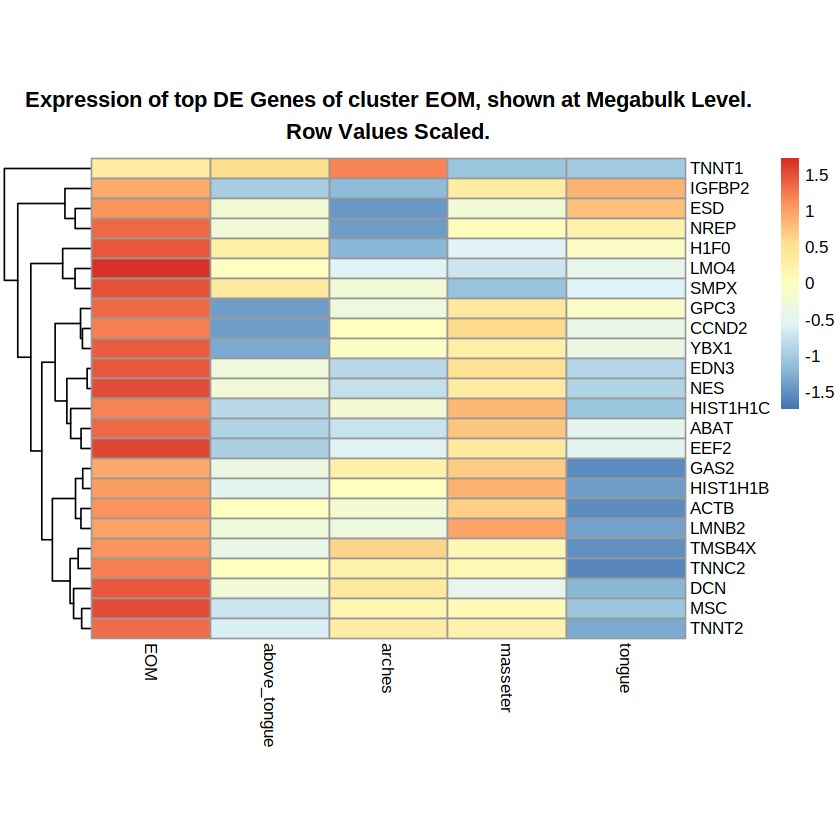

In [90]:
cluster="EOM"
pheatmap_plotting(path, cluster, logCPM, scale_)


agg_record_1588180976 
                    2

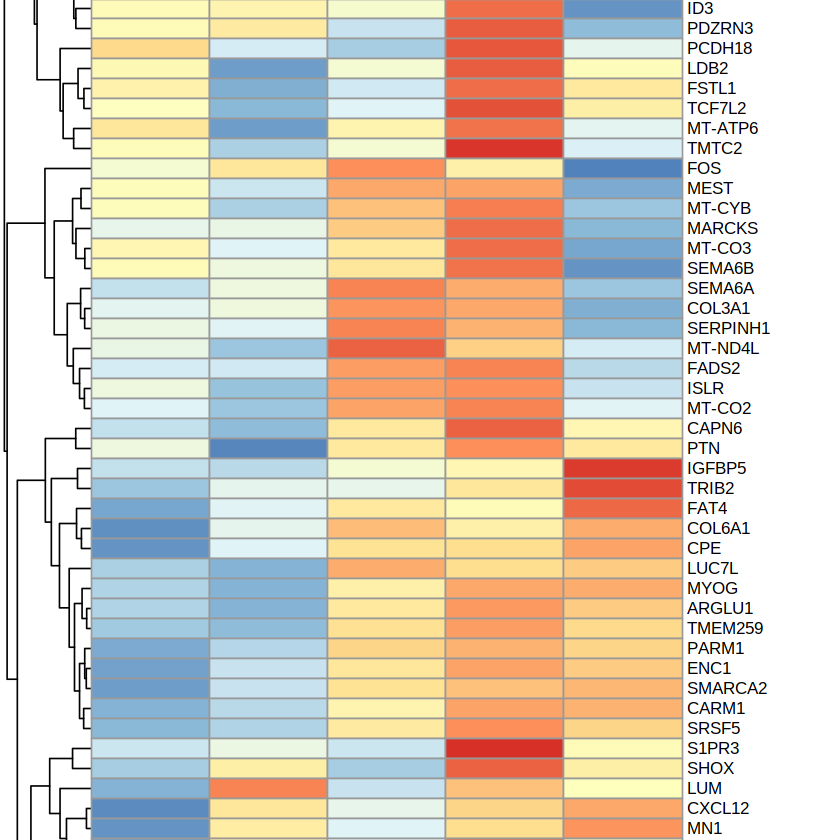

In [91]:
cluster = "masseter"

pheatmap_plotting(path, cluster, logCPM, scale_)

agg_record_957302512 
                   2

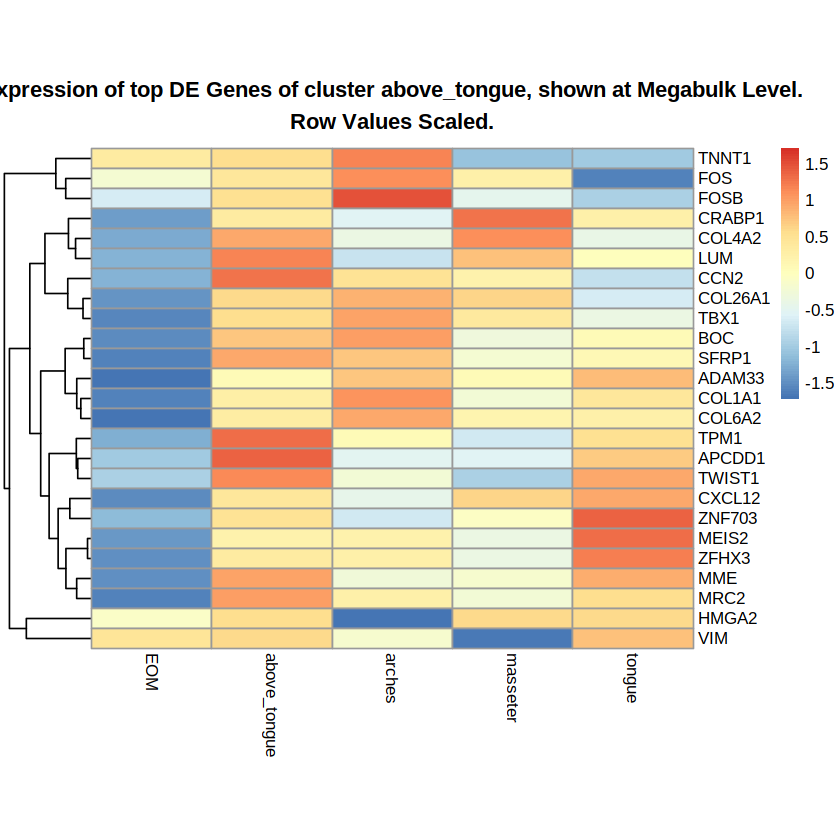

In [92]:
cluster="above_tongue"
pheatmap_plotting(path, cluster, logCPM, scale_)

agg_record_2110458140 
                    2

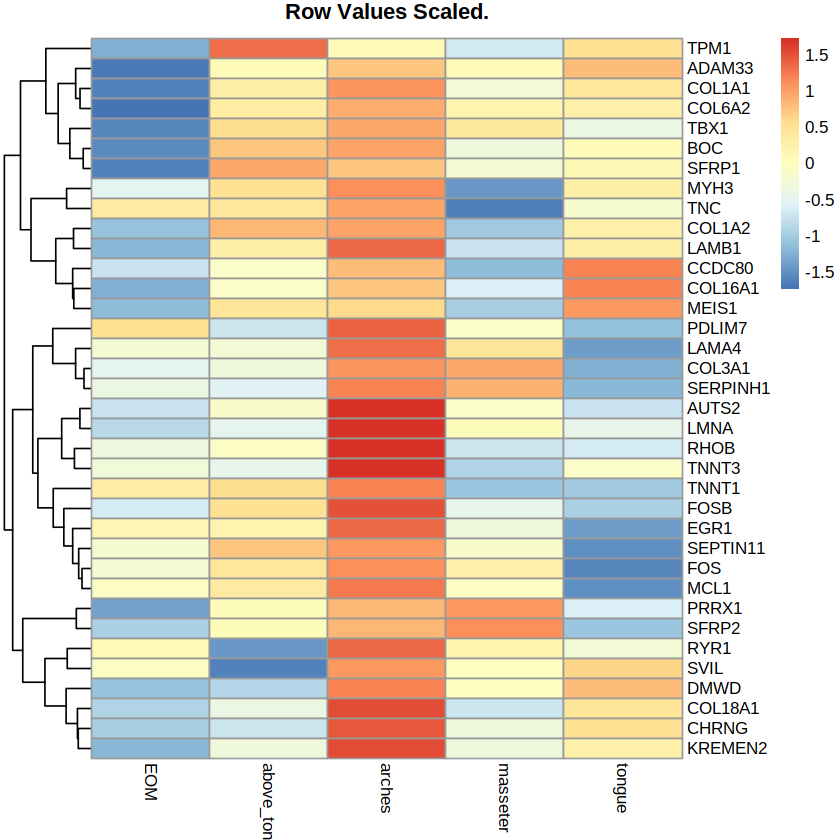

In [93]:
cluster="arches"
pheatmap_plotting(path, cluster, logCPM, scale_)

agg_record_1756277920 
                    2

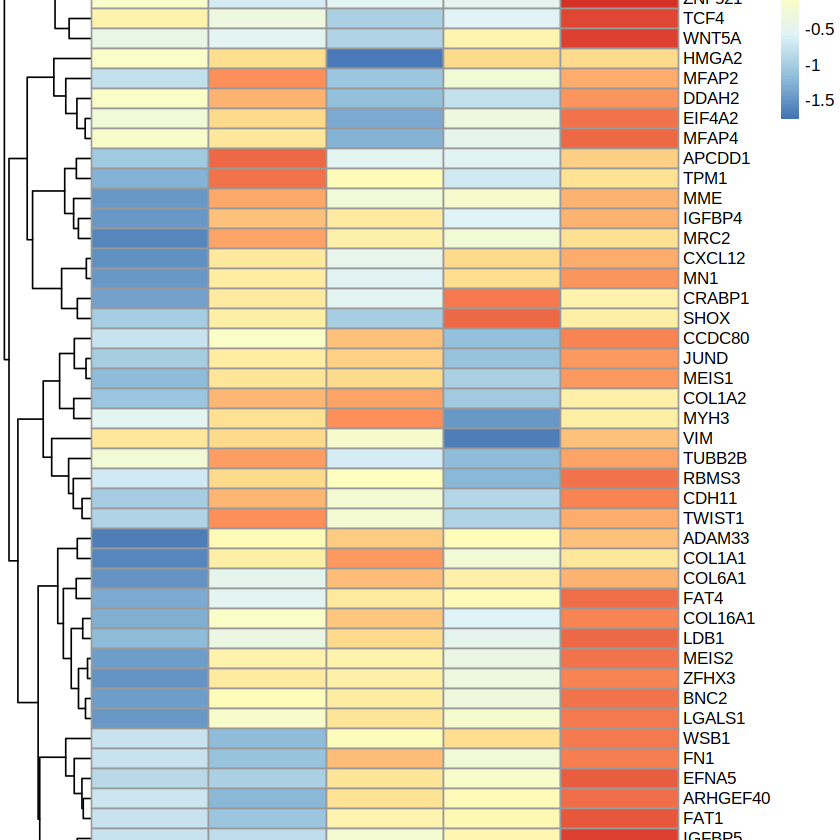

In [94]:
cluster="tongue"
pheatmap_plotting(path, cluster, logCPM, scale_)

### Expression **Not** Scaled

In [95]:
scale_="none"

agg_record_1320769578 
                    2

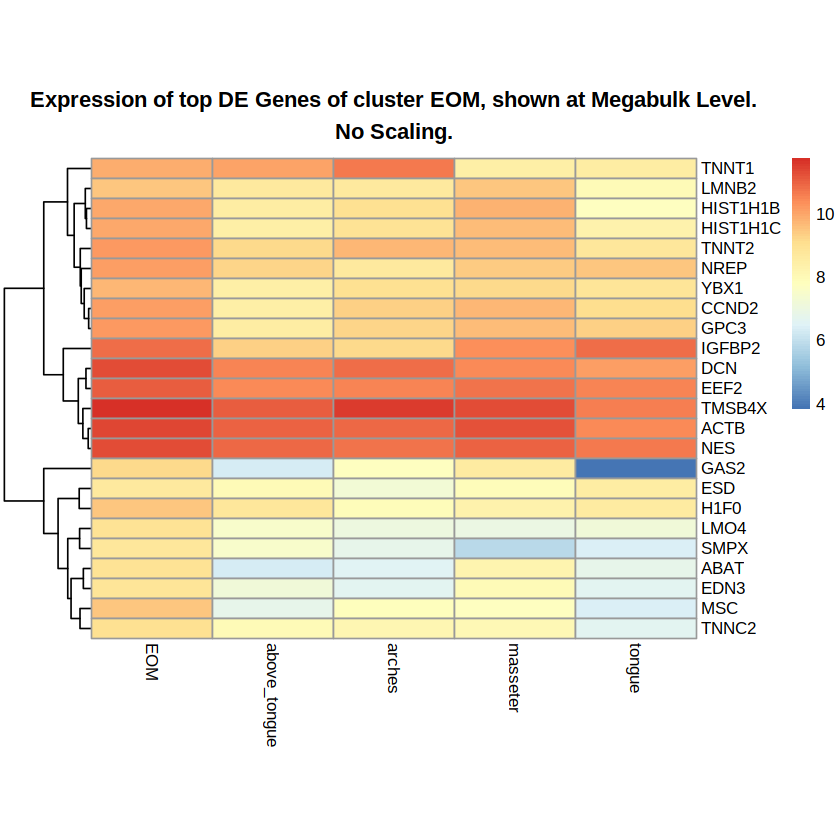

In [96]:
cluster="EOM"
pheatmap_plotting(path, cluster, logCPM, scale_)

agg_record_583224063 
                   2

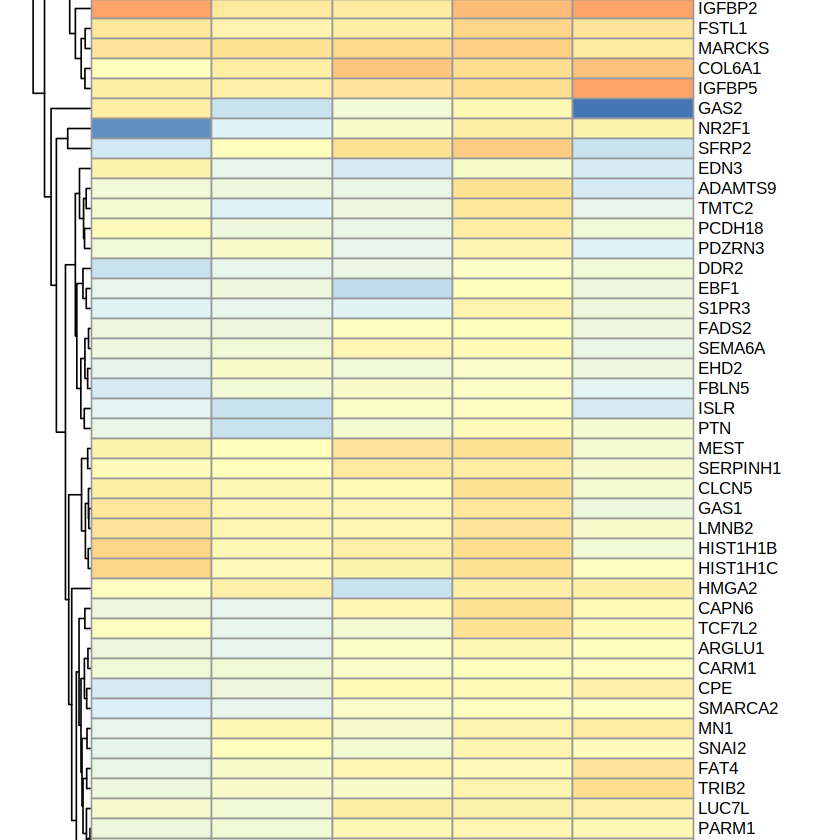

In [97]:
cluster="masseter"
pheatmap_plotting(path, cluster, logCPM, scale_)

agg_record_275946779 
                   2

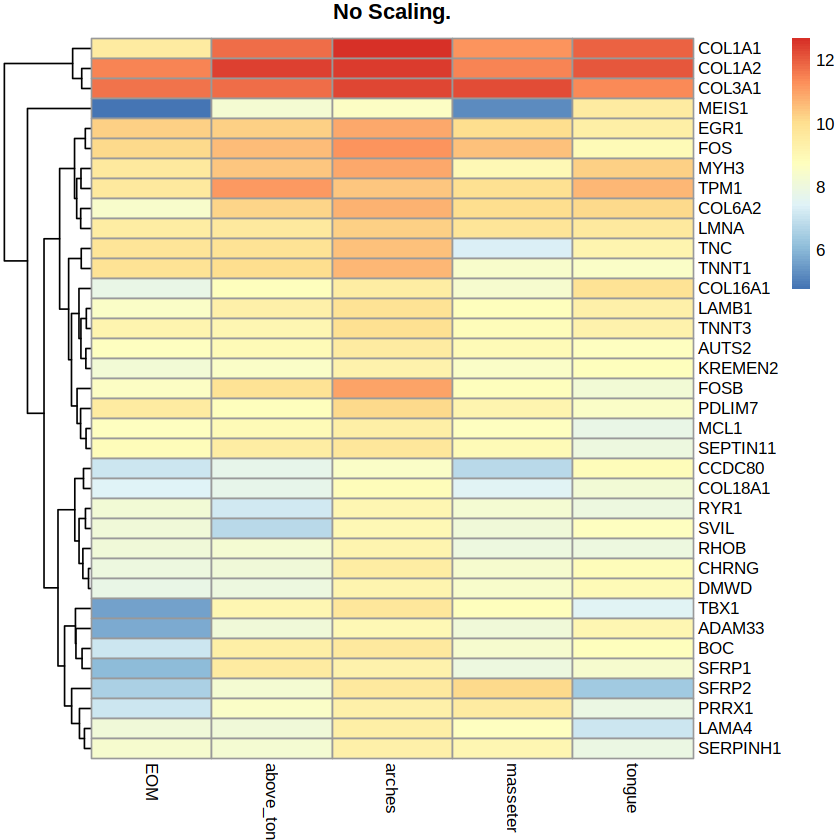

In [98]:
cluster="arches"
pheatmap_plotting(path, cluster, logCPM, scale_)

agg_record_1554247662 
                    2

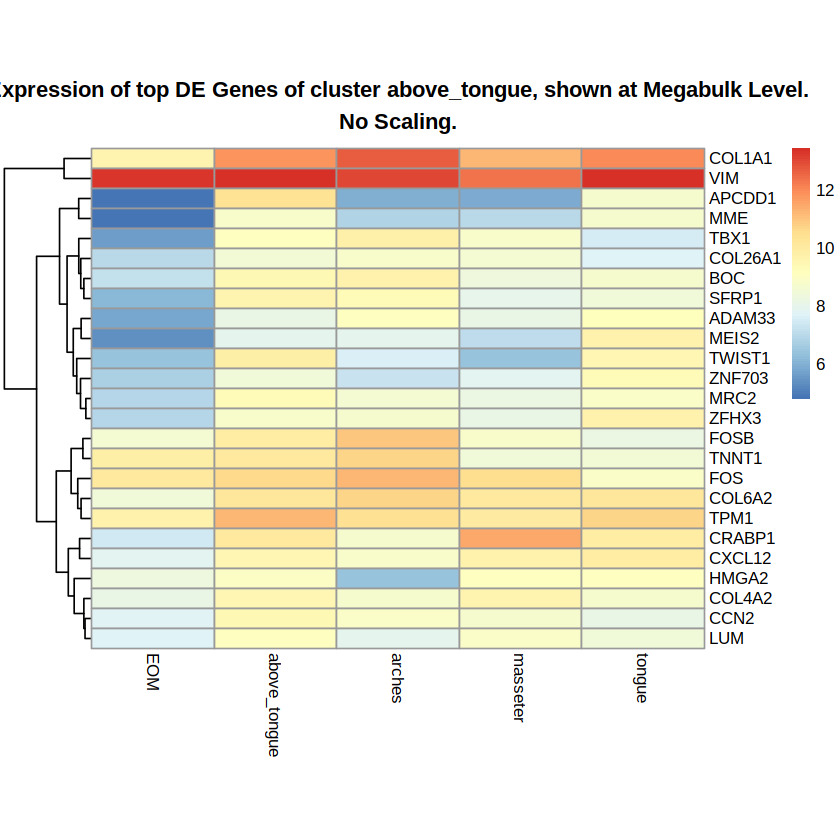

In [99]:
cluster="above_tongue"
pheatmap_plotting(path, cluster, logCPM, scale_)

agg_record_632093684 
                   2

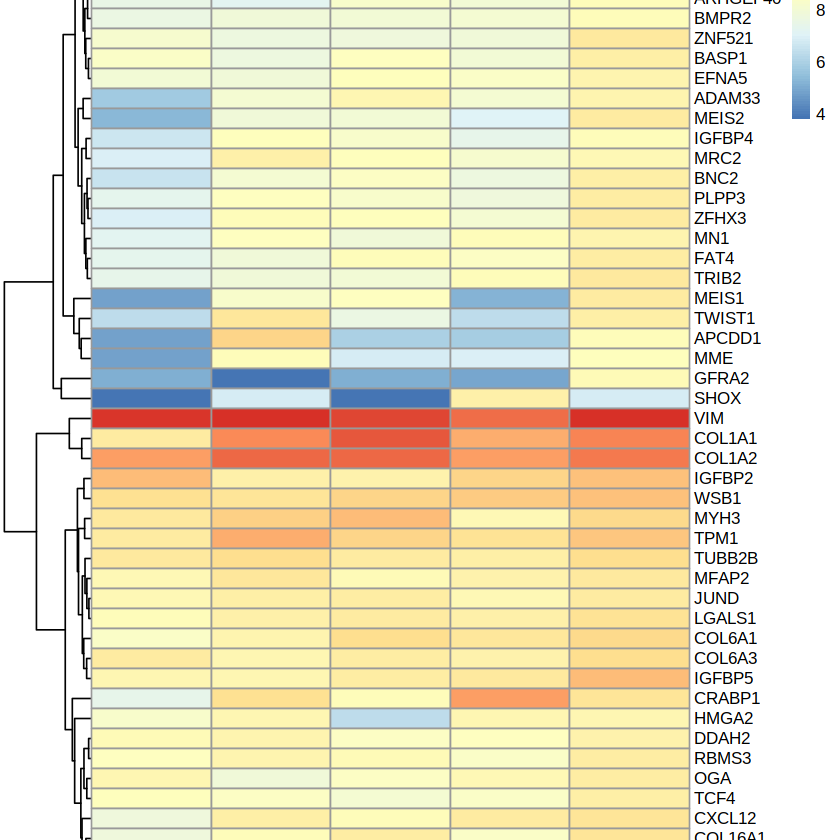

In [100]:
cluster="tongue"
pheatmap_plotting(path, cluster, logCPM, scale_)

## Pheatmaps - Plot genes derived from the single cell analysis

In [146]:
pheatmap_plotting <- function(markers_path, comparison, logCPM, scale_, width=1200, height=2000) { 
    markers_file <- paste0("up_in_",comparison,".tsv")
    tmp <- suppressMessages(readr::read_tsv(paste0(markers_path,markers_file)))
    topGenes <- tmp$names
    if (length(topGenes) < 3) {
        stop("Only plotting for at least 3 markers.")
    }
    if ( length(topGenes) >= 70 ) {
        topGenes <- topGenes[1:70]
    }
    logCPM_top <- logCPM[topGenes, ]
    title <- paste0("Top DE Genes in ", comparison,", shown at Megabulk Level.\n", ifelse(scale_=="none", "No Scaling.", "Row Values Scaled."))
    # Scaling only possible if there are at least two genes
    if ( (length(topGenes) < 2) & (scale_=="row")) {
        print("Scaling not Possible. Too few genes.")
    } else {
        p <- pheatmap(logCPM_top, scale = scale_, cluster_cols = FALSE, main = title, cellheight=12)
        fig_name <- ifelse(scale_=="none", "_not_scaled.png", "_scaled.png")    
        dev.copy(png, paste0("pairwise_comparisons/",comparison,fig_name), width = width, height = height, res=150)
        dev.off()
    }
} 

### Rows scaled

In [172]:
####### Parameters ######
scale_="none"
markers_path_="/pasteur/helix/projects/fast_npz/Naomie/Shahragim_Project/visium_HD/spatial_EOM/segmentation/StarDist/single_cell_DEA_results/"

In [173]:
comparison = "above_tongue_vs_arches"
pheatmap_plotting(markers_path=markers_path_, comparison, logCPM, scale_)

ERROR: Error in pheatmap_plotting(markers_path = markers_path_, comparison, logCPM, : Only plotting for at least 3 markers.


agg_record_1677953671 
                    2

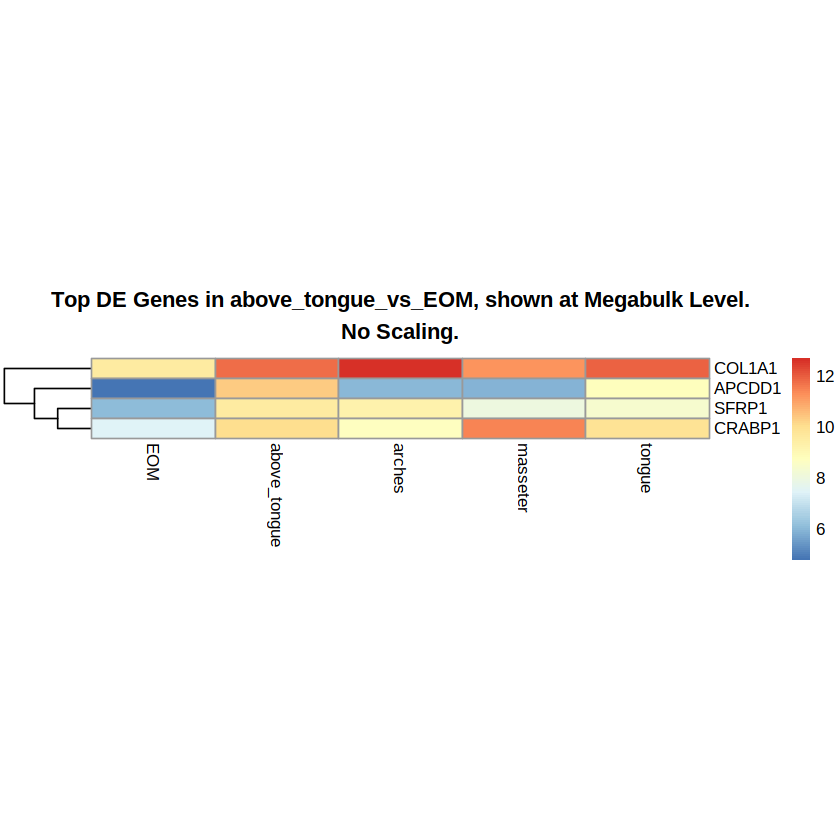

In [174]:
comparison="above_tongue_vs_EOM"
pheatmap_plotting(markers_path=markers_path_, comparison, logCPM, scale_)


In [175]:
comparison = "arches_vs_above_tongue"
pheatmap_plotting(markers_path=markers_path_, comparison, logCPM, scale_)

ERROR: Error in pheatmap_plotting(markers_path = markers_path_, comparison, logCPM, : Only plotting for at least 3 markers.


In [ ]:
comparison="above_tongue_vs_masseter"
pheatmap_plotting(markers_path=markers_path_, comparison, logCPM, scale_)

In [176]:
comparison="above_tongue_vs_tongue"
pheatmap_plotting(markers_path=markers_path_, comparison, logCPM, scale_)


ERROR: Error in pheatmap_plotting(markers_path = markers_path_, comparison, logCPM, : Only plotting for at least 3 markers.


agg_record_205908435 
                   2

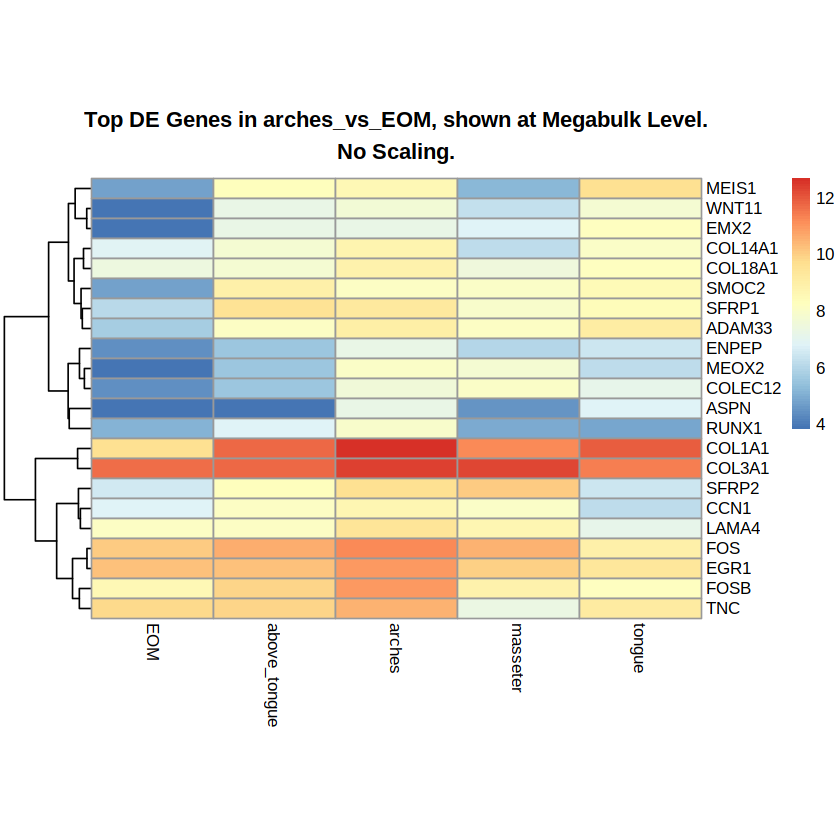

In [177]:
comparison="arches_vs_EOM"
pheatmap_plotting(markers_path=markers_path_, comparison, logCPM, scale_)

agg_record_770679946 
                   2

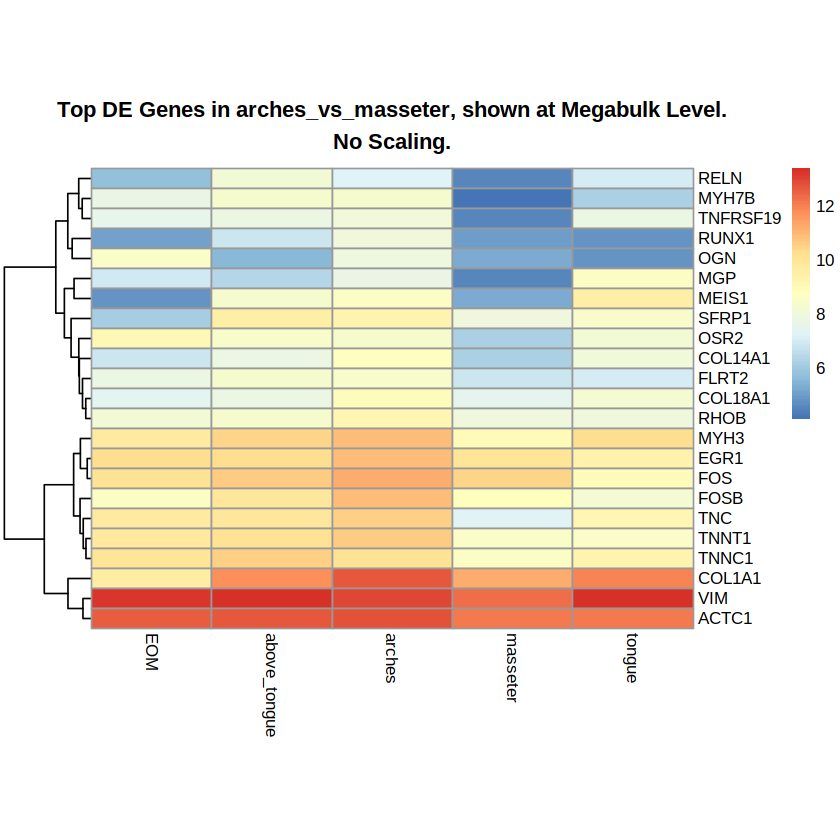

In [178]:
comparison="arches_vs_masseter"
pheatmap_plotting(markers_path=markers_path_, comparison, logCPM, scale_)

agg_record_255302504 
                   2

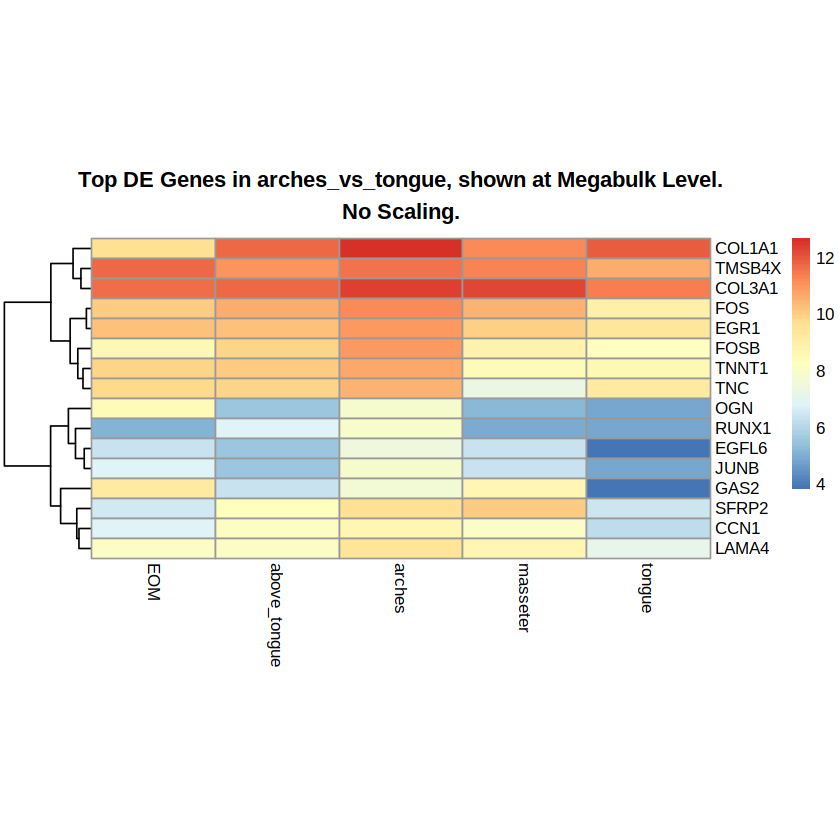

In [179]:
comparison="arches_vs_tongue"
pheatmap_plotting(markers_path=markers_path_, comparison, logCPM, scale_)


agg_record_2124448443 
                    2

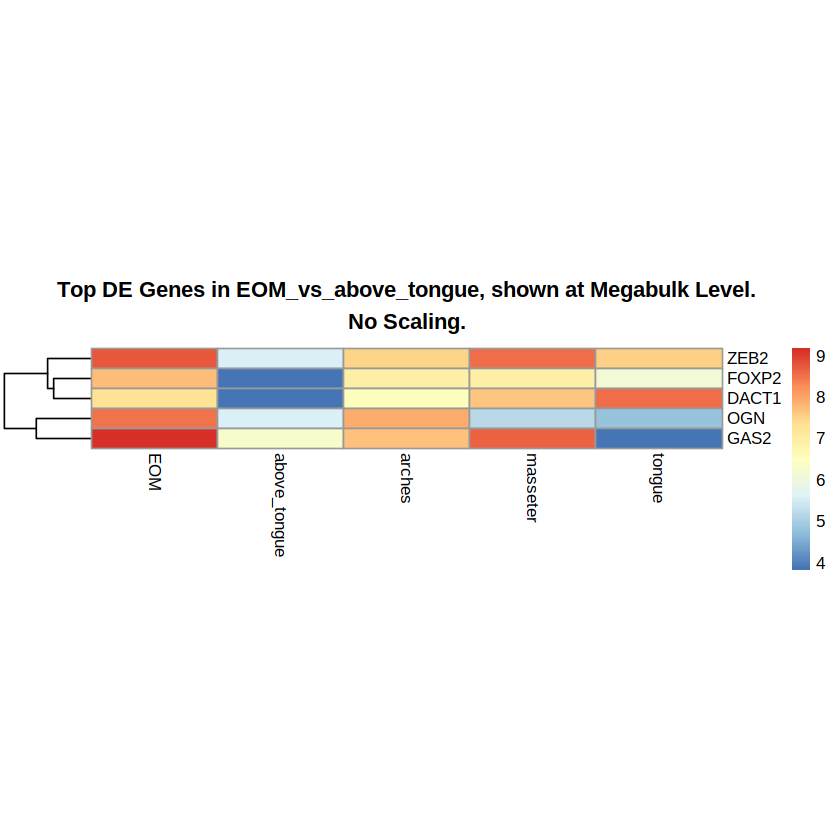

In [180]:
comparison="EOM_vs_above_tongue"
pheatmap_plotting(markers_path=markers_path_, comparison, logCPM, scale_)

agg_record_2107076800 
                    2

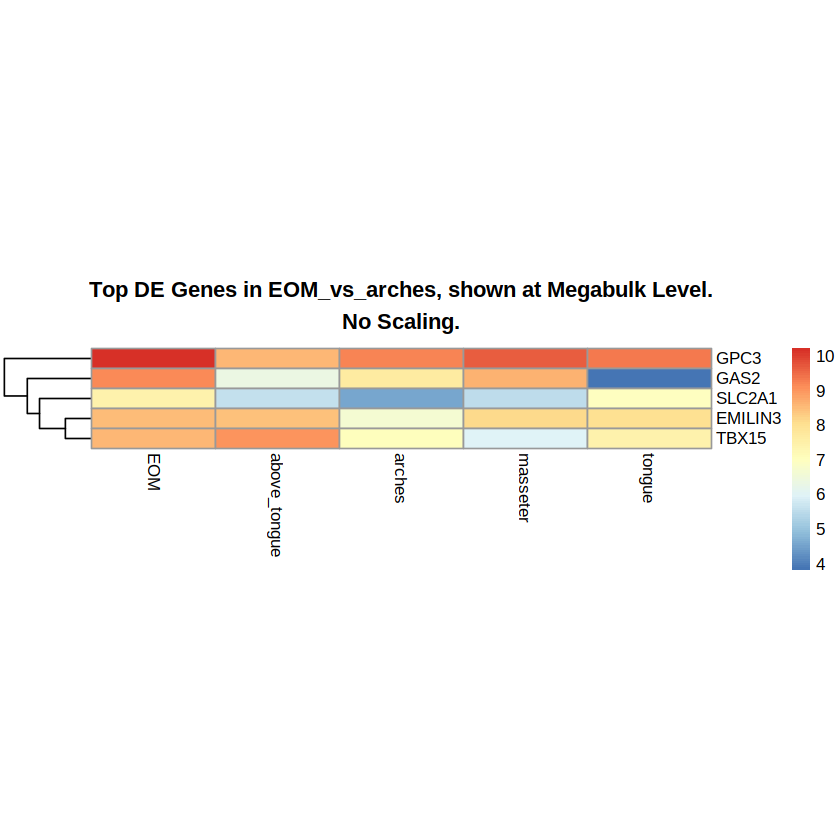

In [181]:
comparison="EOM_vs_arches"
pheatmap_plotting(markers_path=markers_path_, comparison, logCPM, scale_)

agg_record_1380798162 
                    2

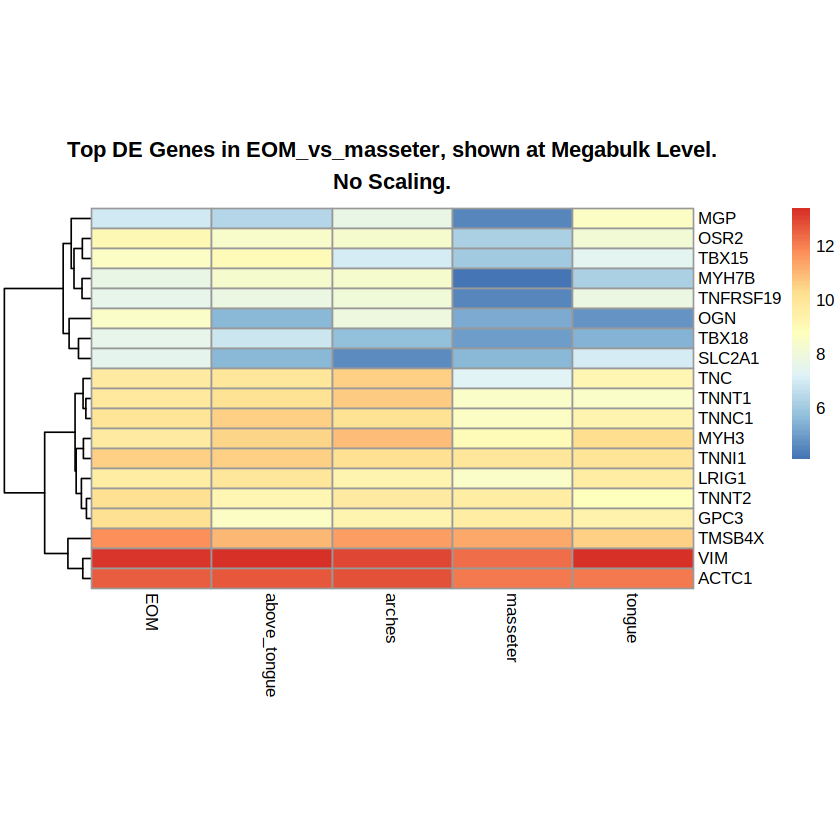

In [182]:
comparison="EOM_vs_masseter"
pheatmap_plotting(markers_path=markers_path_, comparison, logCPM, scale_)

agg_record_863941495 
                   2

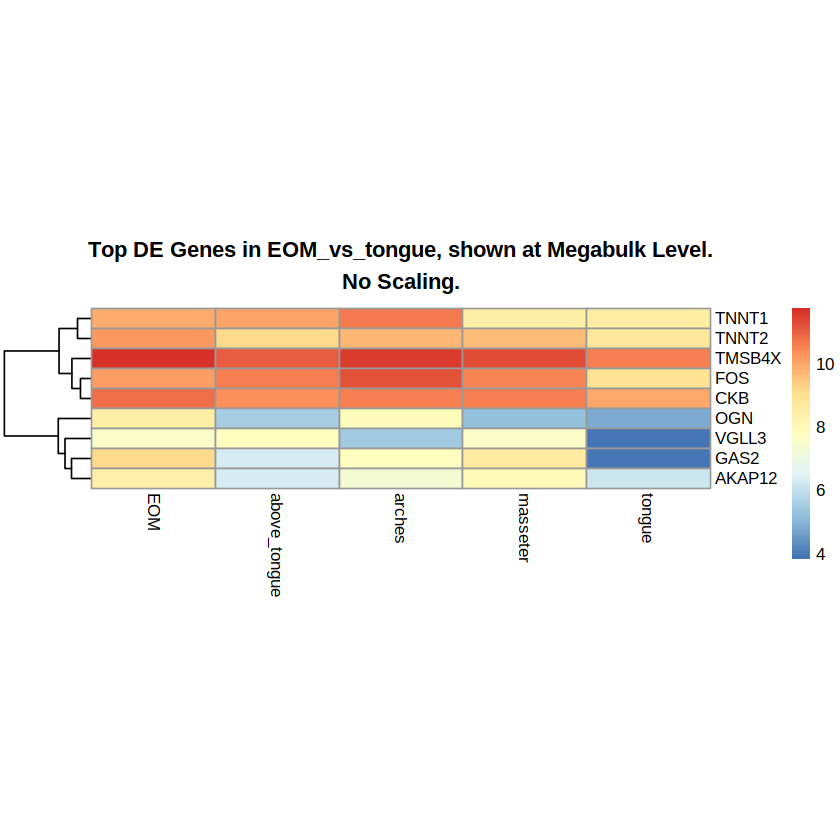

In [183]:
comparison="EOM_vs_tongue"
pheatmap_plotting(markers_path=markers_path_, comparison, logCPM, scale_)


agg_record_1423627838 
                    2

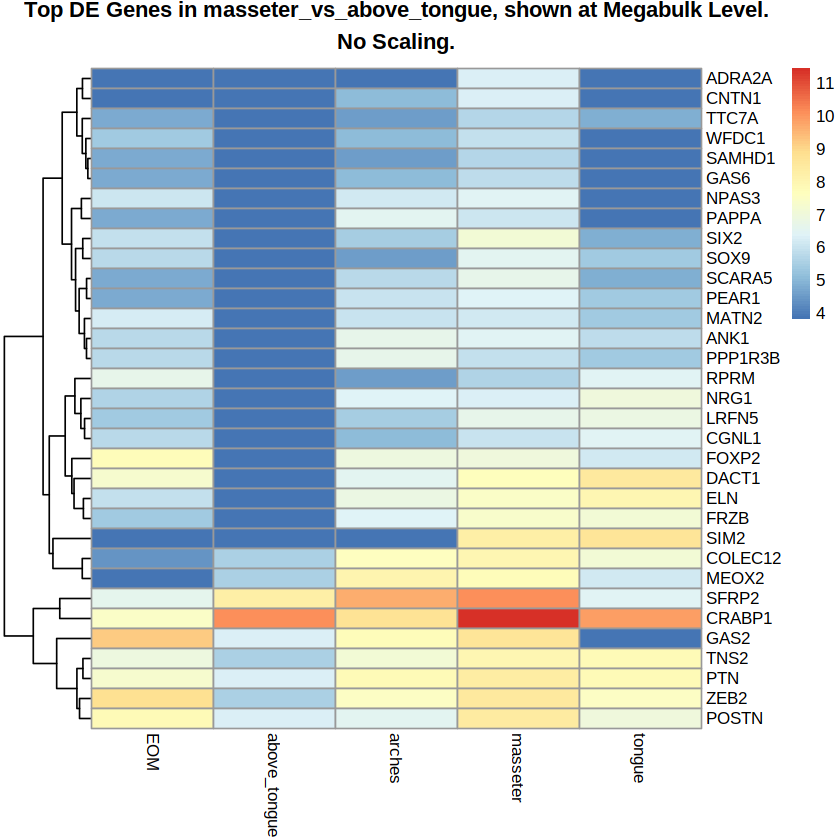

In [184]:
comparison="masseter_vs_above_tongue"
pheatmap_plotting(markers_path=markers_path_, comparison, logCPM, scale_)

agg_record_1438969737 
                    2

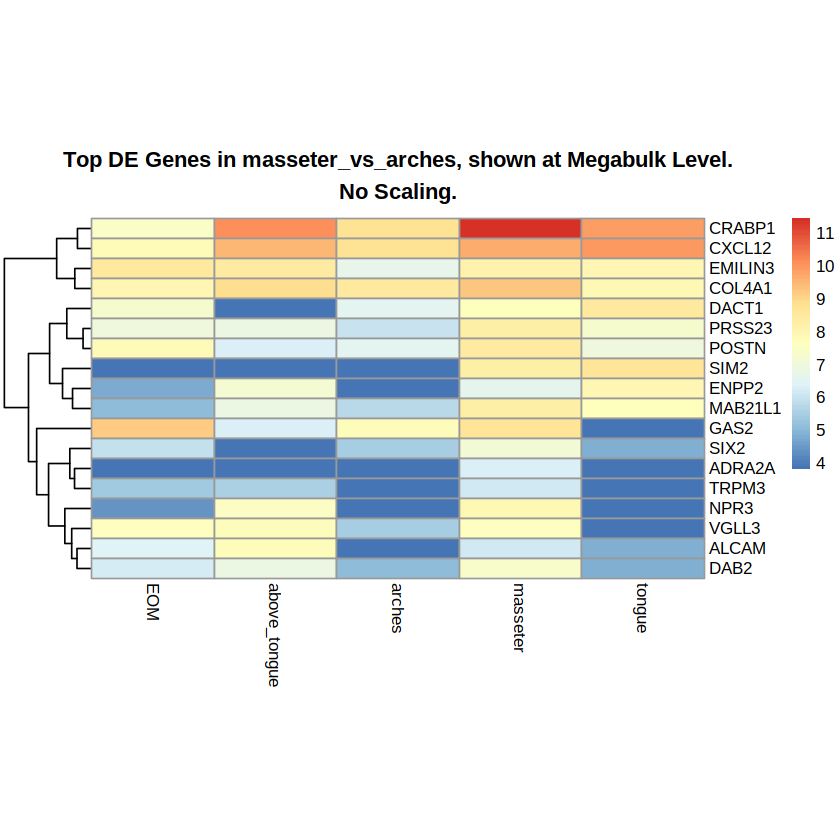

In [185]:
comparison="masseter_vs_arches"
pheatmap_plotting(markers_path=markers_path_, comparison, logCPM, scale_)

agg_record_1844414987 
                    2

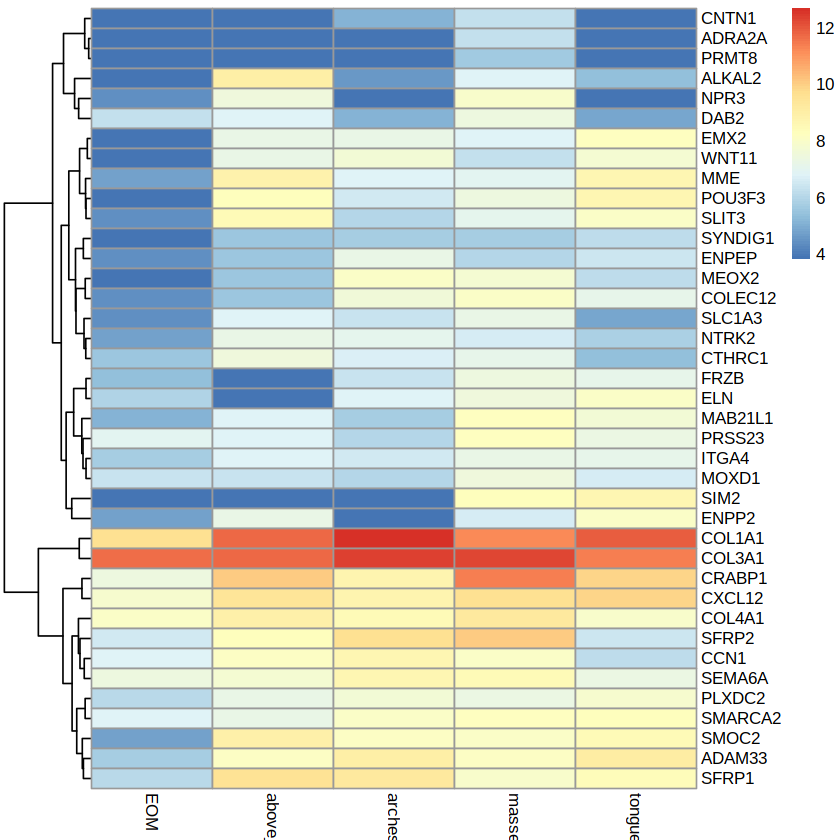

In [186]:
comparison="masseter_vs_EOM"
pheatmap_plotting(markers_path=markers_path_, comparison, logCPM, scale_)

agg_record_1192301421 
                    2

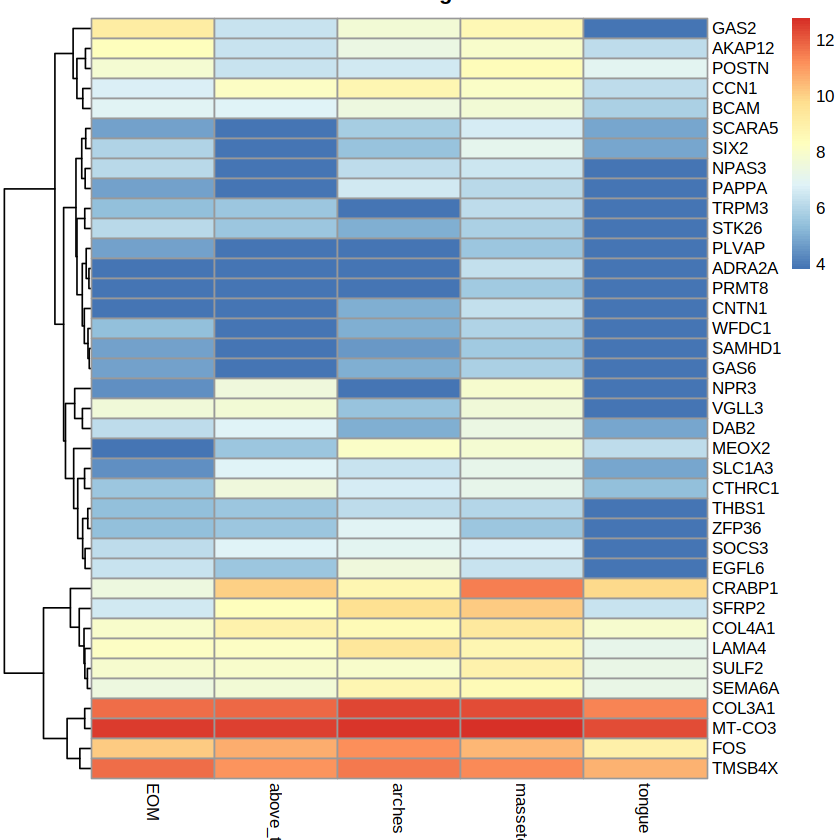

In [187]:
comparison="masseter_vs_tongue"
pheatmap_plotting(markers_path=markers_path_, comparison, logCPM, scale_)


In [188]:
comparison="tongue_vs_above_tongue"
pheatmap_plotting(markers_path=markers_path_, comparison, logCPM, scale_)

ERROR: Error in pheatmap_plotting(markers_path = markers_path_, comparison, logCPM, : Only plotting for at least 3 markers.


agg_record_1726240264 
                    2

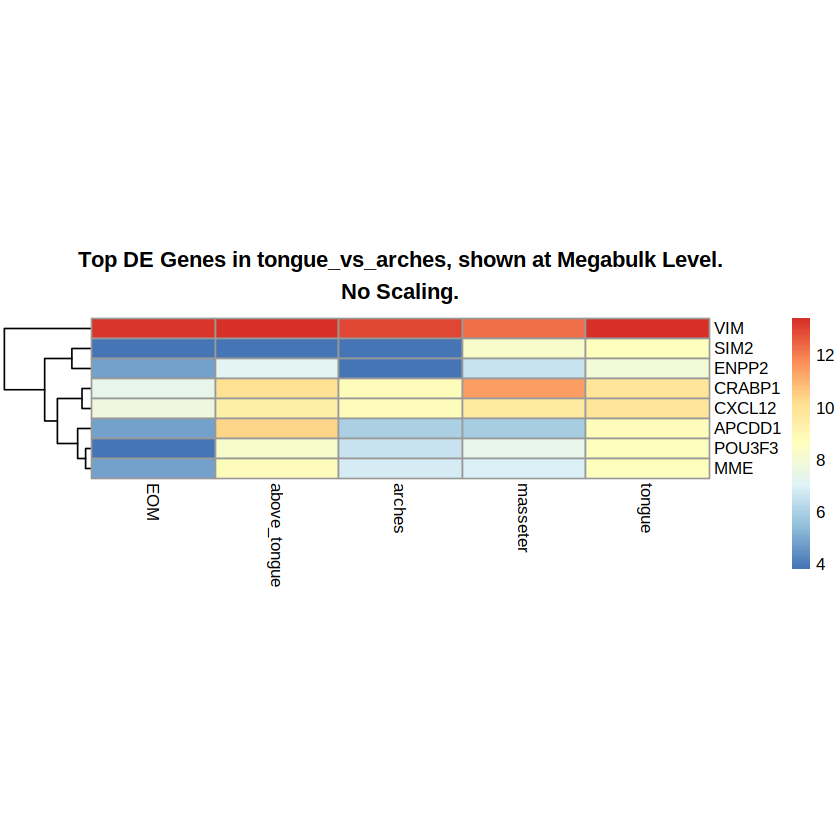

In [189]:
comparison="tongue_vs_arches"
pheatmap_plotting(markers_path=markers_path_, comparison, logCPM, scale_)

agg_record_1985081006 
                    2

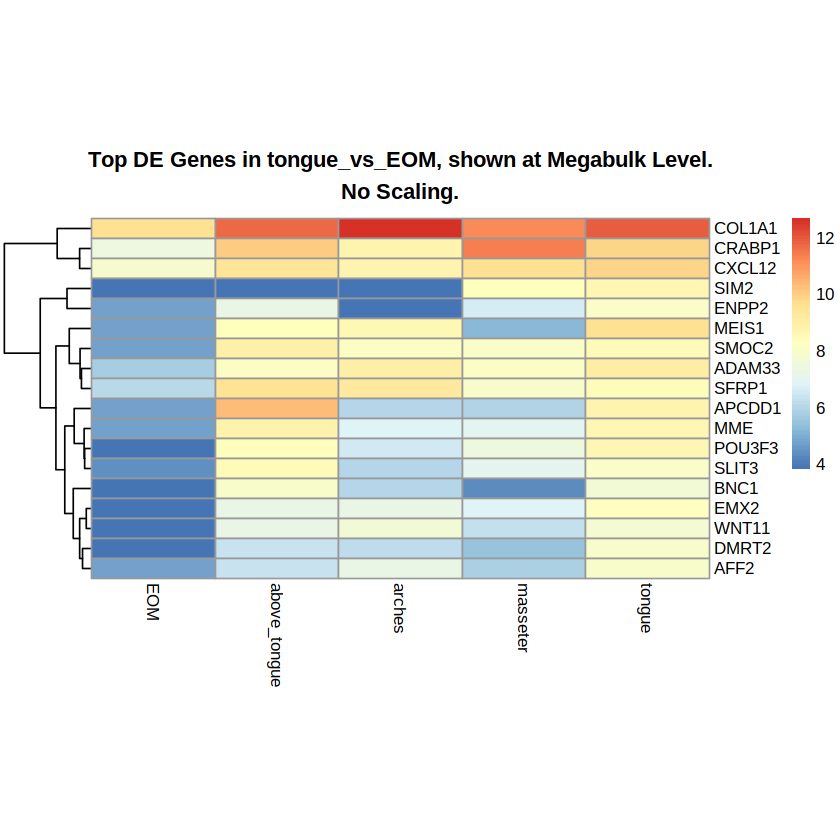

In [190]:
comparison="tongue_vs_EOM"
pheatmap_plotting(markers_path=markers_path_, comparison, logCPM, scale_)

agg_record_2099392820 
                    2

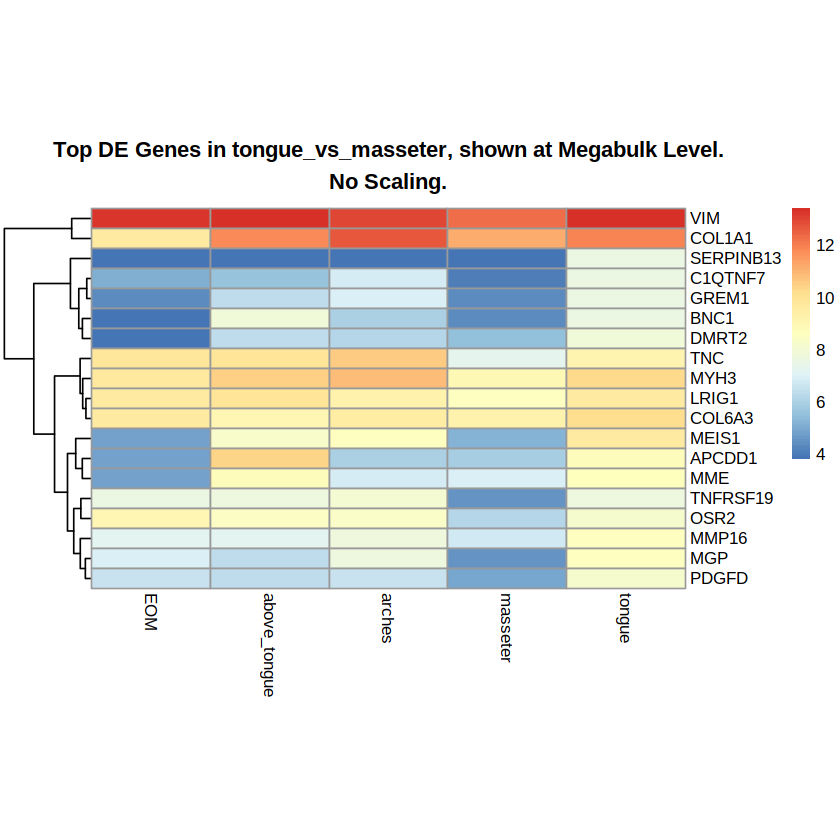

In [191]:
comparison="tongue_vs_masseter"
pheatmap_plotting(markers_path=markers_path_, comparison, logCPM, scale_)

### No Scaling

In [116]:
scale_="none"